<div style="background-color: #111A33; padding: 28px; border-radius: 10px; text-align: center; color: white; margin-bottom: 25px; box-shadow: 0 4px 8px rgba(0,0,0,0.15);">
    <h1 style="margin: 0; font-size: 34px; font-weight: bold; color: #FFFFFF;">
        DebtStream SMS A/B Testing Analysis (Fintech)
    </h1>
    <p style="margin: 12px 0 0 0; font-size: 19px; color: #F47B20; font-weight: bold;">
        Direct Payment Reminder vs Supportive Repayment Messaging
    </p>
    <p style="margin: 8px 0 0 0; font-size: 15px; color: #D9E2EC;">
        A/B Testing | Statistical Significance | Customer Behaviour | Repayment Plan Setup
    </p>
</div>

<h2 style="color: #0f172a; border-left: 5px solid #F47B20; padding-left: 12px; margin-top: 30px; font-weight: bold;">
Project Context & Objective
</h2>

In this notebook, I am analysing DebtStream's SMS A/B test to understand whether a **supportive repayment-options message** performed better than a **direct payment reminder**.

The experiment was designed to test whether message tone influences customer behaviour in the digital collections journey. The Control group received a more direct payment reminder, while the Variant group received a supportive message focused on repayment options.

The objective of this notebook is to compare engagement, payment, repayment plan setup, and recovery outcomes between the two groups, and then test whether the observed differences are statistically meaningful or mainly directional.

<h2 style="color: #0f172a; border-left: 5px solid #F47B20; padding-left: 12px; margin-top: 30px; font-weight: bold;">
The Analytical Pipeline
</h2>

This notebook follows a structured A/B testing workflow:

**1. Load A/B Test Data**  
Load the customer-level A/B test dataset and SQL-exported performance summaries created during the BigQuery phase.

**2. Validate Experiment Population**  
Check Control and Variant group sizes to confirm that the test population is suitable for comparison.

**3. Compare Core Metrics**  
Compare link open rate, payment rate, one-off payment rate, repayment plan setup rate, amount collected, and recovery rate.

**4. Visualise Control vs Variant Outcomes**  
Create clear visuals showing where the supportive message improved performance and where it did not.

**5. Run Statistical Tests**  
Use two-proportion z-tests for binary outcomes and a t-test for amount collected.

**6. Segment by Balance Band**  
Analyse whether the message effect differs across Low, Medium, and High balance customers.

**7. Summarise Business Recommendation**  
Turn the statistical and business findings into a practical recommendation for message strategy.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 1: Experiment Design
</h2>

**Define the A/B Test Setup**

The SMS A/B test compares two message approaches:

| Group | Message Tone | Description |
|---|---|---|
| Control | Direct | A direct payment reminder asking the customer to take repayment action |
| Variant | Supportive | A supportive message highlighting repayment options and flexibility |

The unit of analysis is the **customer**, not the individual SMS event. This is important because a customer can receive multiple communications, but for A/B testing each customer should be counted once.

The test population was prepared in BigQuery as a customer-level dataset using the first eligible SMS test message for each customer between **January 2023 and March 2023**.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 2: Library Imports and Project Setup
</h2>

**Import Libraries and Configure Paths**

I am importing the Python libraries required for data analysis, visualisation, and statistical testing. I am also defining the project folder paths for loading SQL-exported A/B test outputs and saving charts or result tables.

In [1]:
# ============================================================
# Section 2: Library Imports and Project Setup
# ============================================================

# 1. Import core data analysis libraries
import pandas as pd
import numpy as np

# 2. Import visualisation libraries
import matplotlib.pyplot as plt

# 3. Import statistical testing libraries
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import ttest_ind

# 4. Import operating system library for file paths
import os

# 5. Set pandas display options for easier inspection
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:,.2f}'.format)

# 6. Set simple global chart formatting
#    Charts are intentionally kept clean
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# 7. Define project folder paths
#    This assumes the notebook is saved inside the /notebooks folder.
BASE_PATH = os.path.abspath(os.path.join(os.getcwd(), '..'))
SUMMARY_TABLES_PATH = os.path.join(BASE_PATH, 'outputs', 'summary_tables')
CHARTS_PATH = os.path.join(BASE_PATH, 'outputs', 'charts')

# 8. Create output folders if they do not already exist
os.makedirs(CHARTS_PATH, exist_ok=True)
os.makedirs(SUMMARY_TABLES_PATH, exist_ok=True)

print("Libraries imported successfully.")
print("Project paths configured.")
print("Base path:", BASE_PATH)

Libraries imported successfully.
Project paths configured.
Base path: C:\Users\Utkarsh\DebtStream_Digital_Collections_Project


<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 3: Load A/B Test Data
</h2>

**Load SQL-Exported A/B Test Outputs**

I am loading the SQL-exported A/B test files created during the BigQuery phase.

The most important file is `ab_test_customer_outcomes.csv`, which contains one row per A/B test customer. This customer-level dataset will be used for statistical testing.

The other files provide SQL-validated summary outputs that will be used for comparison charts and business interpretation.

In [2]:
# ============================================================
# Section 3: Load A/B Test Data
# ============================================================

# 1. Load customer-level A/B test dataset
ab_test_customers = pd.read_csv(os.path.join(SUMMARY_TABLES_PATH, 'ab_test_customer_outcomes.csv'))

# 2. Load SQL summary outputs
ab_test_core_performance = pd.read_csv(os.path.join(SUMMARY_TABLES_PATH, 'ab_test_core_performance.csv'))
ab_test_by_balance_band = pd.read_csv(os.path.join(SUMMARY_TABLES_PATH, 'ab_test_by_balance_band.csv'))
ab_test_lift_summary = pd.read_csv(os.path.join(SUMMARY_TABLES_PATH, 'ab_test_lift_summary.csv'))

print("A/B test datasets loaded successfully.")

A/B test datasets loaded successfully.


In [3]:
# 3. Preview customer-level A/B test dataset
ab_test_customers.head()

,customer_id,client_id,client_type,industry,integration_type,portfolio_type,debt_balance,balance_band,debt_age_days,debt_age_band,customer_age_band,region,vulnerability_flag,account_status,sms_sent_date,ab_test_group,message_tone,delivered_flag,communication_opened_or_clicked_flag,link_opened_flag,identity_verified_flag,balance_viewed_flag,payment_option_selected_flag,payment_made_flag,one_off_payment_flag,amount_collected,avg_successful_payment_amount,repayment_plan_created_flag,first_instalment_paid_flag,broken_plan_flag,affordability_completed_flag,max_missed_payment_count,customer_recovery_rate
0,DCUST000003,DSC002,Utility Provider,Utilities,Hybrid,Early Arrears,50.21,Low,31,31-90,55+,South East,0,Paid,2023-01-02,Control,Direct,1,1,1,1,1,1,1,1,43.03,43.03,0,0,0,0,0,0.86
1,DCUST000004,DSC001,Utility Provider,Utilities,API,Late Arrears,377.38,Medium,60,31-90,45-54,East Midlands,0,No Engagement,2023-03-24,Control,Direct,1,0,0,0,0,0,0,0,0.00,0.00,0,0,0,0,0,0.00
2,DCUST000009,DSC007,Debt Purchaser,Collections,Batch Upload,Purchased Debt,"1,998.76",High,681,365+,45-54,South East,0,No Engagement,2023-03-26,Control,Direct,1,0,0,0,0,0,0,0,0.00,0.00,0,0,0,0,0,0.00
3,DCUST000013,DSC007,Debt Purchaser,Collections,Batch Upload,Late Arrears,313.78,Medium,169,91-180,45-54,Northern Ireland,0,No Engagement,2023-01-01,Control,Direct,1,0,0,0,0,0,0,0,0.00,0.00,0,0,0,0,0,0.00
4,DCUST000015,DSC007,Debt Purchaser,Collections,Batch Upload,Purchased Debt,834.57,Medium,466,365+,55+,South East,0,No Engagement,2023-03-02,Control,Direct,1,0,0,0,0,0,0,0,0.00,0.00,0,0,0,0,0,0.00


In [4]:
# 4. Check the shape of each A/B test dataset
ab_test_shapes = pd.DataFrame({
    'dataset': [
        'ab_test_customers',
        'ab_test_core_performance',
        'ab_test_by_balance_band',
        'ab_test_lift_summary'
    ],
    'rows': [
        ab_test_customers.shape[0],
        ab_test_core_performance.shape[0],
        ab_test_by_balance_band.shape[0],
        ab_test_lift_summary.shape[0]
    ],
    'columns': [
        ab_test_customers.shape[1],
        ab_test_core_performance.shape[1],
        ab_test_by_balance_band.shape[1],
        ab_test_lift_summary.shape[1]
    ]
})

ab_test_shapes

,dataset,rows,columns
0,ab_test_customers,1936,33
1,ab_test_core_performance,2,14
2,ab_test_by_balance_band,6,9
3,ab_test_lift_summary,1,7


**Insight & Business Takeaway**

The A/B test datasets loaded successfully. The customer-level dataset contains 1,936 customers, while the summary files provide Control vs Variant performance, balance-band segmentation, and lift calculations.

**Indication:** The A/B test analysis can proceed using customer-level data rather than communication-event-level data, which avoids double-counting customers who may have received multiple SMS messages.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 4: Validate A/B Test Population
</h2>

**Check Control and Variant Group Sizes**

Before comparing outcomes, I am checking how many customers are in the Control and Variant groups.

The test groups do not need to be perfectly equal, but they should be reasonably balanced so that the comparison is meaningful.

In [5]:
# ============================================================
# Section 4: Validate A/B Test Population
# ============================================================

# 1. Count customers by A/B test group
ab_group_sizes = (
    ab_test_customers
    .groupby('ab_test_group')
    .agg(customers=('customer_id', 'nunique'))
    .reset_index()
)

# 2. Add customer share percentage
ab_group_sizes['customer_share_percent'] = (
    ab_group_sizes['customers'] / ab_group_sizes['customers'].sum() * 100
)

ab_group_sizes

,ab_test_group,customers,customer_share_percent
0,Control,929,47.99
1,Variant,1007,52.01


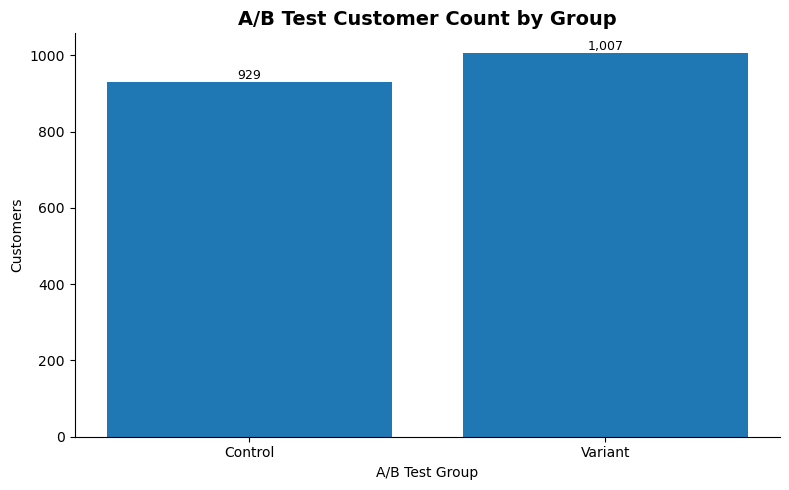

In [6]:
# 3. Plot A/B test group sizes
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    ab_group_sizes['ab_test_group'],
    ab_group_sizes['customers']
)

ax.set_title('A/B Test Customer Count by Group', fontsize=14, fontweight='bold')
ax.set_xlabel('A/B Test Group')
ax.set_ylabel('Customers')

# 4. Add value labels
for index, value in enumerate(ab_group_sizes['customers']):
    ax.text(index, value, f'{value:,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'ab_test_customer_count_by_group.png'), dpi=300, bbox_inches='tight')
plt.show()

**Insight & Business Takeaway**

The A/B test population is reasonably balanced, with 929 customers in the Control group and 1,007 customers in the Variant group.

The Variant group is slightly larger, but the difference is not large enough to prevent meaningful comparison. Because each row represents one customer, the experiment can be analysed at customer level without inflating results through repeated SMS events.

**Indication:** The test population is suitable for comparing customer engagement and repayment outcomes between the two message strategies.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 5: Core A/B Test Metric Comparison
</h2>

**Compare Control vs Variant Performance**

I am now comparing the main A/B test metrics between the Control and Variant groups.

The Control group received a direct payment reminder, while the Variant group received a supportive repayment-options message. This section compares whether the supportive message improved digital engagement, payment behaviour, repayment plan setup, and recovery outcomes.

In [7]:
# ============================================================
# Section 5: Core A/B Test Metric Comparison
# ============================================================

# 1. Display SQL-exported Control vs Variant performance summary
ab_test_core_performance

,ab_test_group,test_customers,link_open_rate,identity_verification_rate,balance_view_rate,payment_option_selection_rate,payment_rate,one_off_payment_rate,plan_setup_rate,first_instalment_paid_rate,broken_plan_rate,total_amount_collected,avg_amount_collected_per_customer,avg_customer_recovery_rate
0,Control,929,40.47,27.34,24.87,19.05,11.09,6.78,6.14,4.52,3.44,"27,821.23",29.95,6.20
1,Variant,1007,44.19,29.49,27.51,21.85,13.51,4.77,10.53,8.94,2.68,"36,603.29",36.35,7.38


In [8]:
# 2. Select the most important metrics for comparison
core_metrics = ab_test_core_performance[
    [
        'ab_test_group',
        'test_customers',
        'link_open_rate',
        'payment_rate',
        'one_off_payment_rate',
        'plan_setup_rate',
        'first_instalment_paid_rate',
        'broken_plan_rate',
        'avg_amount_collected_per_customer',
        'avg_customer_recovery_rate'
    ]
].copy()

# 3. Display selected core metrics
core_metrics

,ab_test_group,test_customers,link_open_rate,payment_rate,one_off_payment_rate,plan_setup_rate,first_instalment_paid_rate,broken_plan_rate,avg_amount_collected_per_customer,avg_customer_recovery_rate
0,Control,929,40.47,11.09,6.78,6.14,4.52,3.44,29.95,6.20
1,Variant,1007,44.19,13.51,4.77,10.53,8.94,2.68,36.35,7.38


**Insight & Business Takeaway**

The Variant group performs better than the Control group across several important customer outcomes, including link open rate, payment rate, repayment plan setup rate, first instalment paid rate, average amount collected per customer, and average customer recovery rate.

However, the Control group performs better on one-off payment rate. This suggests that a direct reminder may be more effective for customers who are ready to make an immediate payment, while a supportive repayment-options message may be more effective for encouraging customers to set up repayment plans.

**Indication:** The supportive message should not automatically replace the direct reminder for every customer. The stronger strategy is likely to use message tone based on customer segment and repayment intent.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 6: Visual Comparison of Control vs Variant
</h2>

**Visualise the Main Experiment Outcomes**

I am creating simple comparison charts to show where the Variant message outperformed the Control message and where it did not.

These visuals help translate the A/B test results into a clearer business story before running statistical tests.

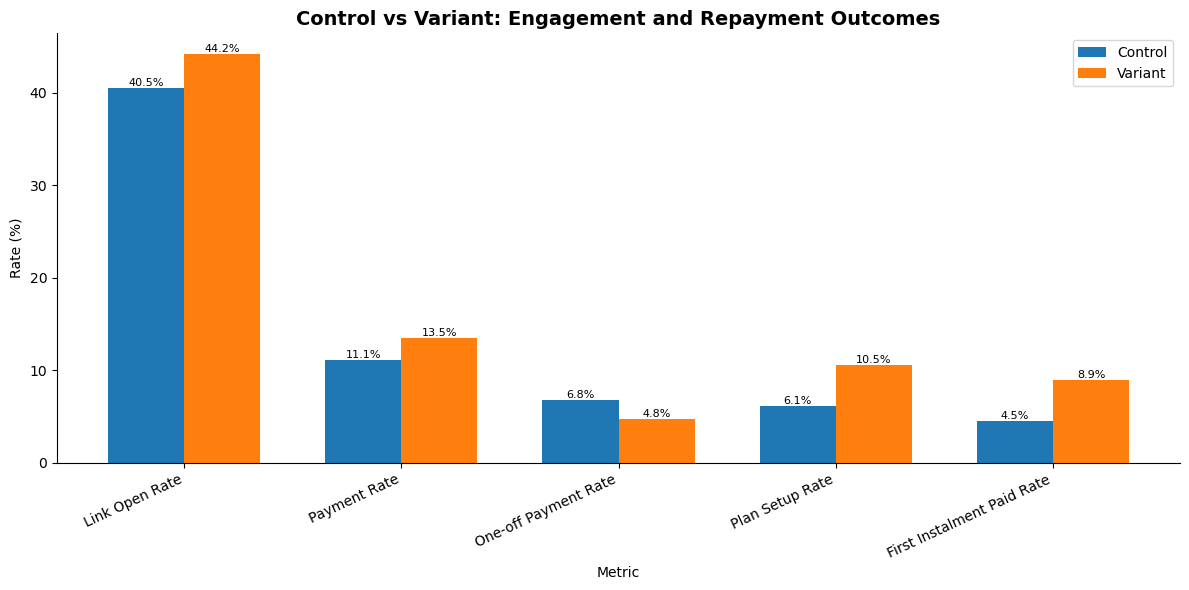

In [9]:
# ============================================================
# Section 6: Visual Comparison of Control vs Variant
# ============================================================

# 1. Prepare metrics for grouped bar chart
comparison_metrics = [
    'link_open_rate',
    'payment_rate',
    'one_off_payment_rate',
    'plan_setup_rate',
    'first_instalment_paid_rate'
]

# 2. Convert data from wide to long format for plotting
comparison_long = ab_test_core_performance.melt(
    id_vars='ab_test_group',
    value_vars=comparison_metrics,
    var_name='metric',
    value_name='rate'
)

# 3. Rename metrics for chart readability
metric_labels = {
    'link_open_rate': 'Link Open Rate',
    'payment_rate': 'Payment Rate',
    'one_off_payment_rate': 'One-off Payment Rate',
    'plan_setup_rate': 'Plan Setup Rate',
    'first_instalment_paid_rate': 'First Instalment Paid Rate'
}

comparison_long['metric_label'] = comparison_long['metric'].map(metric_labels)

# 4. Create grouped bar chart
metric_order = list(metric_labels.values())
x = np.arange(len(metric_order))
width = 0.35

control_values = (
    comparison_long[comparison_long['ab_test_group'] == 'Control']
    .set_index('metric_label')
    .loc[metric_order, 'rate']
)

variant_values = (
    comparison_long[comparison_long['ab_test_group'] == 'Variant']
    .set_index('metric_label')
    .loc[metric_order, 'rate']
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x - width / 2, control_values, width, label='Control')
ax.bar(x + width / 2, variant_values, width, label='Variant')

ax.set_title('Control vs Variant: Engagement and Repayment Outcomes', fontsize=14, fontweight='bold')
ax.set_xlabel('Metric')
ax.set_ylabel('Rate (%)')
ax.set_xticks(x)
ax.set_xticklabels(metric_order, rotation=25, ha='right')
ax.legend()

# 5. Add value labels
for index, value in enumerate(control_values):
    ax.text(index - width / 2, value, f'{value:.1f}%', ha='center', va='bottom', fontsize=8)

for index, value in enumerate(variant_values):
    ax.text(index + width / 2, value, f'{value:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'ab_test_control_vs_variant_core_rates.png'), dpi=300, bbox_inches='tight')
plt.show()

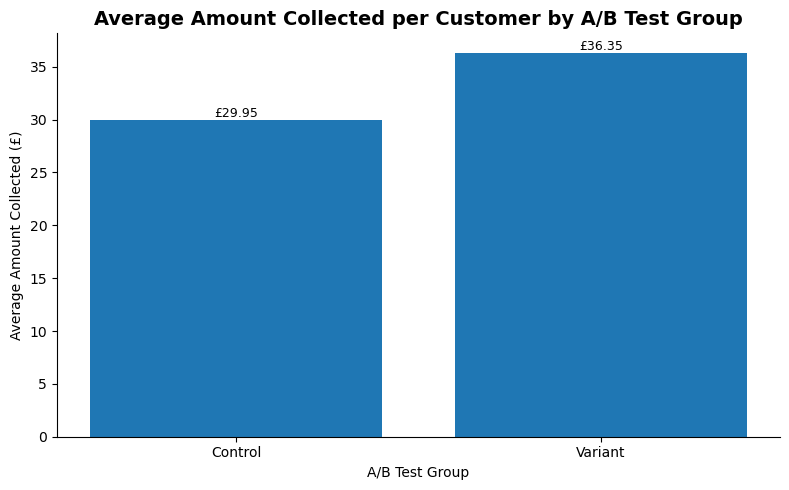

In [10]:
# 6. Plot average amount collected per customer by group
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    ab_test_core_performance['ab_test_group'],
    ab_test_core_performance['avg_amount_collected_per_customer']
)

ax.set_title('Average Amount Collected per Customer by A/B Test Group', fontsize=14, fontweight='bold')
ax.set_xlabel('A/B Test Group')
ax.set_ylabel('Average Amount Collected (£)')

# 7. Add value labels
for index, value in enumerate(ab_test_core_performance['avg_amount_collected_per_customer']):
    ax.text(index, value, f'£{value:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'ab_test_avg_amount_collected_per_customer.png'), dpi=300, bbox_inches='tight')
plt.show()

**Insight & Business Takeaway**

The visual comparison shows a clear directional improvement for the Variant group across link open rate, payment rate, plan setup rate, first instalment paid rate, and average amount collected per customer.

The main exception is one-off payment rate, where the Control group performs better. This is commercially important because it suggests that direct payment reminders may work better for customers who are ready to pay immediately, while supportive repayment messaging may work better for customers who need flexibility.

**Indication:** The A/B test does not suggest one universal winning message for every customer. Instead, it supports a more segmented messaging strategy.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 7: Variant Lift Summary
</h2>

**Quantify the Lift from Control to Variant**

I am using the SQL-exported `ab_test_lift_summary.csv` file to quantify how much the Variant message improved or reduced each key outcome compared with the Control group.

This provides a clear business summary of the experiment before applying statistical significance testing.

In [11]:
# ============================================================
# Section 7: Variant Lift Summary
# ============================================================

# 1. Display SQL-exported lift summary
ab_test_lift_summary

,comparison,link_open_rate_point_lift,payment_rate_point_lift,one_off_payment_rate_point_lift,plan_setup_rate_point_lift,avg_recovery_rate_point_lift,avg_amount_collected_per_customer_lift
0,Variant vs Control,3.72,2.42,-2.01,4.39,1.18,6.40


In [12]:
# 2. Prepare lift summary for plotting
lift_chart_data = pd.DataFrame({
    'metric': [
        'Link Open Rate',
        'Payment Rate',
        'One-off Payment Rate',
        'Plan Setup Rate',
        'Avg Recovery Rate'
    ],
    'point_lift': [
        ab_test_lift_summary.loc[0, 'link_open_rate_point_lift'],
        ab_test_lift_summary.loc[0, 'payment_rate_point_lift'],
        ab_test_lift_summary.loc[0, 'one_off_payment_rate_point_lift'],
        ab_test_lift_summary.loc[0, 'plan_setup_rate_point_lift'],
        ab_test_lift_summary.loc[0, 'avg_recovery_rate_point_lift']
    ]
})

lift_chart_data

,metric,point_lift
0,Link Open Rate,3.72
1,Payment Rate,2.42
2,One-off Payment Rate,-2.01
3,Plan Setup Rate,4.39
4,Avg Recovery Rate,1.18


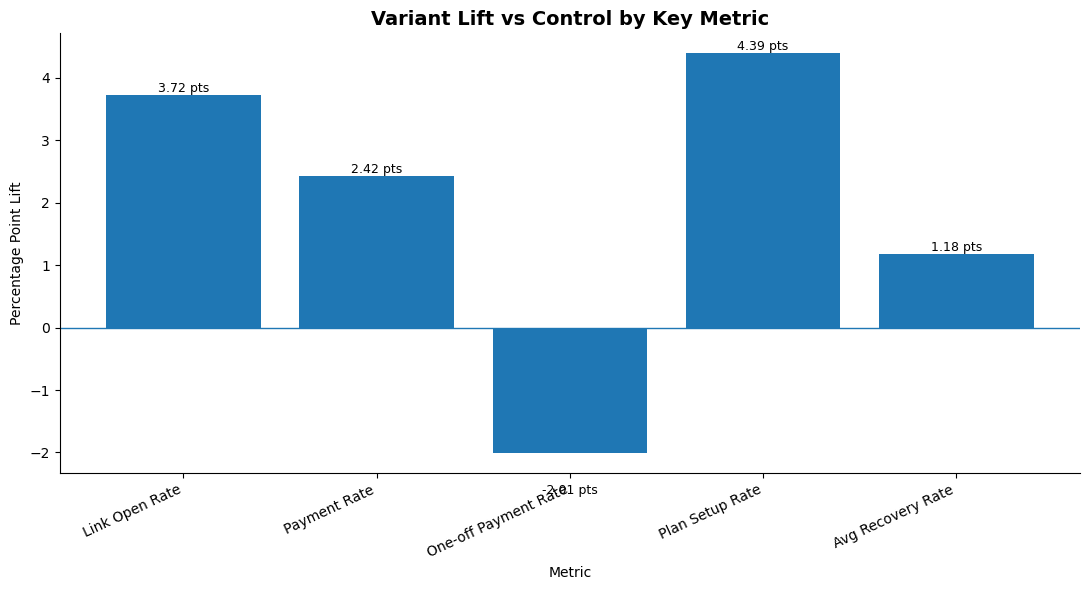

In [13]:
# 3. Plot lift summary
fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(
    lift_chart_data['metric'],
    lift_chart_data['point_lift']
)

ax.axhline(0, linewidth=1)

ax.set_title('Variant Lift vs Control by Key Metric', fontsize=14, fontweight='bold')
ax.set_xlabel('Metric')
ax.set_ylabel('Percentage Point Lift')

plt.xticks(rotation=25, ha='right')

# 4. Add value labels
for index, value in enumerate(lift_chart_data['point_lift']):
    label_position = value if value >= 0 else value - 0.5
    va_position = 'bottom' if value >= 0 else 'top'
    ax.text(index, label_position, f'{value:.2f} pts', ha='center', va=va_position, fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'ab_test_variant_lift_summary.png'), dpi=300, bbox_inches='tight')
plt.show()

**Insight & Business Takeaway**

The Variant message delivered a positive lift across several important outcomes, including link open rate, payment rate, plan setup rate, average recovery rate, and average amount collected per customer.

The strongest practical lift appears in repayment plan setup, where the supportive message outperformed the direct reminder by more than four percentage points. However, the one-off payment rate shows a negative lift, meaning the Control message performed better for immediate one-off payments.

**Indication:** The Variant message appears stronger for encouraging flexible repayment behaviour, while the Control message may still be useful for customers with higher readiness to make a direct payment.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 8: Statistical Significance Testing
</h2>

**Test Whether the A/B Differences are Statistically Meaningful**

The visual comparison shows that the Variant group performs better across several important outcomes, especially repayment plan setup. However, visual differences alone are not enough to confirm whether the results are statistically meaningful.

In this section, I am using **two-proportion z-tests** to compare Control vs Variant outcomes for binary customer behaviours such as link open, payment made, one-off payment, repayment plan setup, first instalment paid, and broken plan.

The purpose is to separate:
- outcomes that are statistically significant,
- outcomes that are directionally positive but not statistically significant,
- and outcomes where the Control group performed better.

In [14]:
# ============================================================
# Section 8: Statistical Significance Testing
# ============================================================

# 1. Create a helper function to run a two-proportion z-test
def run_proportion_ztest(dataframe, metric_column, metric_name):
    
    # 2. Split the data into Control and Variant groups
    control_group = dataframe[dataframe['ab_test_group'] == 'Control']
    variant_group = dataframe[dataframe['ab_test_group'] == 'Variant']
    
    # 3. Count successes for each group
    control_successes = control_group[metric_column].sum()
    variant_successes = variant_group[metric_column].sum()
    
    # 4. Count total customers in each group
    control_total = control_group['customer_id'].nunique()
    variant_total = variant_group['customer_id'].nunique()
    
    # 5. Calculate observed rates
    control_rate = control_successes / control_total
    variant_rate = variant_successes / variant_total
    
    # 6. Run two-proportion z-test
    count = np.array([variant_successes, control_successes])
    nobs = np.array([variant_total, control_total])
    
    z_stat, p_value = proportions_ztest(count, nobs)
    
    # 7. Calculate lift in percentage points
    lift_percentage_points = (variant_rate - control_rate) * 100
    
    # 8. Interpret statistical significance
    if p_value < 0.05:
        significance = 'Statistically significant'
    else:
        significance = 'Not statistically significant'
    
    # 9. Interpret direction
    if lift_percentage_points > 0:
        direction = 'Variant higher'
    elif lift_percentage_points < 0:
        direction = 'Control higher'
    else:
        direction = 'No difference'
    
    # 10. Return results as a dictionary
    return {
        'metric': metric_name,
        'control_successes': control_successes,
        'control_total': control_total,
        'control_rate_percent': control_rate * 100,
        'variant_successes': variant_successes,
        'variant_total': variant_total,
        'variant_rate_percent': variant_rate * 100,
        'lift_percentage_points': lift_percentage_points,
        'z_statistic': z_stat,
        'p_value': p_value,
        'significance': significance,
        'direction': direction
    }


print("Two-proportion z-test helper function created successfully.")

Two-proportion z-test helper function created successfully.


In [15]:
# 11. Define binary metrics to test
binary_metrics = [
    ('link_opened_flag', 'Link Open Rate'),
    ('payment_made_flag', 'Payment Rate'),
    ('one_off_payment_flag', 'One-off Payment Rate'),
    ('repayment_plan_created_flag', 'Plan Setup Rate'),
    ('first_instalment_paid_flag', 'First Instalment Paid Rate'),
    ('broken_plan_flag', 'Broken Plan Rate')
]

# 12. Run z-tests for all selected binary outcomes
ztest_results = []

for metric_column, metric_name in binary_metrics:
    result = run_proportion_ztest(
        dataframe=ab_test_customers,
        metric_column=metric_column,
        metric_name=metric_name
    )
    ztest_results.append(result)

# 13. Convert results into a dataframe
ztest_results_df = pd.DataFrame(ztest_results)

# 14. Round numeric columns for readability
ztest_results_df[
    [
        'control_rate_percent',
        'variant_rate_percent',
        'lift_percentage_points',
        'z_statistic',
        'p_value'
    ]
] = ztest_results_df[
    [
        'control_rate_percent',
        'variant_rate_percent',
        'lift_percentage_points',
        'z_statistic',
        'p_value'
    ]
].round(4)

# 15. Display z-test results
ztest_results_df

,metric,control_successes,control_total,control_rate_percent,variant_successes,variant_total,variant_rate_percent,lift_percentage_points,z_statistic,p_value,significance,direction
0,Link Open Rate,376,929,40.47,445,1007,44.19,3.72,1.65,0.10,Not statistically significant,Variant higher
1,Payment Rate,103,929,11.09,136,1007,13.51,2.42,1.62,0.11,Not statistically significant,Variant higher
2,One-off Payment Rate,63,929,6.78,48,1007,4.77,-2.01,-1.91,0.06,Not statistically significant,Control higher
3,Plan Setup Rate,57,929,6.14,106,1007,10.53,4.39,3.48,0.00,Statistically significant,Variant higher
4,First Instalment Paid Rate,42,929,4.52,90,1007,8.94,4.42,3.85,0.00,Statistically significant,Variant higher
5,Broken Plan Rate,32,929,3.44,27,1007,2.68,-0.76,-0.98,0.33,Not statistically significant,Control higher


**Insight & Business Takeaway**

The two-proportion z-tests show which behavioural differences between Control and Variant are statistically meaningful.

The most important metric to evaluate is **repayment plan setup rate**, because the supportive message was designed to encourage customers to consider flexible repayment options. If the Variant shows a statistically significant lift in plan setup rate, this provides strong evidence that supportive messaging is more effective for customers who need repayment flexibility.

The one-off payment result should be interpreted separately. If the Control group performs better on one-off payment rate, that does not necessarily mean the Variant failed. It may mean that direct payment reminders are better for customers who are already ready to make an immediate payment, while supportive messaging works better for customers who need a repayment plan.

**Indication:** Statistical testing should support a segmented messaging strategy rather than a single universal winner.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 9: Amount Collected Analysis
</h2>

**Test and Interpret Amount Collected per Customer**

The previous section already visualised average amount collected per customer by A/B test group. In this section, I am adding a statistical view of the same commercial outcome.

I am using an independent samples t-test to compare `amount_collected` between Control and Variant customers. This helps assess whether the difference in average amount collected is statistically meaningful.

This result should be interpreted carefully because collections payment data is usually zero-heavy and skewed. Many customers may have £0 collected, while a smaller number of customers may have contributed larger payment amounts. For this reason, I am also reviewing the share of customers with any amount collected.

In [22]:
# ============================================================
# Section 9: Amount Collected Analysis
# ============================================================

# 1. Split amount collected by A/B test group
control_amounts = ab_test_customers[
    ab_test_customers['ab_test_group'] == 'Control'
]['amount_collected']

variant_amounts = ab_test_customers[
    ab_test_customers['ab_test_group'] == 'Variant'
]['amount_collected']

# 2. Run Welch's t-test
#    equal_var=False is used because group variances may not be identical.
t_statistic, ttest_p_value = ttest_ind(
    variant_amounts,
    control_amounts,
    equal_var=False
)

# 3. Calculate summary values
control_avg_amount = control_amounts.mean()
variant_avg_amount = variant_amounts.mean()
amount_lift = variant_avg_amount - control_avg_amount

# 4. Create t-test result dataframe
amount_ttest_result = pd.DataFrame({
    'metric': ['Amount Collected per Customer'],
    'control_avg_amount': [control_avg_amount],
    'variant_avg_amount': [variant_avg_amount],
    'amount_lift': [amount_lift],
    't_statistic': [t_statistic],
    'p_value': [ttest_p_value],
    'significance': [
        'Statistically significant' if ttest_p_value < 0.05 else 'Not statistically significant'
    ]
})

# 5. Round numeric columns
amount_ttest_result[
    ['control_avg_amount', 'variant_avg_amount', 'amount_lift', 't_statistic', 'p_value']
] = amount_ttest_result[
    ['control_avg_amount', 'variant_avg_amount', 'amount_lift', 't_statistic', 'p_value']
].round(4)

amount_ttest_result

,metric,control_avg_amount,variant_avg_amount,amount_lift,t_statistic,p_value,significance
0,Amount Collected per Customer,29.95,36.35,6.40,1.10,0.27,Not statistically significant


In [23]:
# 6. Create amount collected summary by A/B test group
amount_summary = (
    ab_test_customers
    .groupby('ab_test_group')
    .agg(
        avg_amount_collected=('amount_collected', 'mean'),
        median_amount_collected=('amount_collected', 'median'),
        customers=('customer_id', 'nunique'),
        customers_with_collection=('amount_collected', lambda x: (x > 0).sum())
    )
    .reset_index()
)

# 7. Calculate share of customers with any amount collected
amount_summary['collection_customer_rate'] = (
    amount_summary['customers_with_collection'] / amount_summary['customers'] * 100
)

amount_summary

,ab_test_group,avg_amount_collected,median_amount_collected,customers,customers_with_collection,collection_customer_rate
0,Control,29.95,0.00,929,103,11.09
1,Variant,36.35,0.00,1007,136,13.51


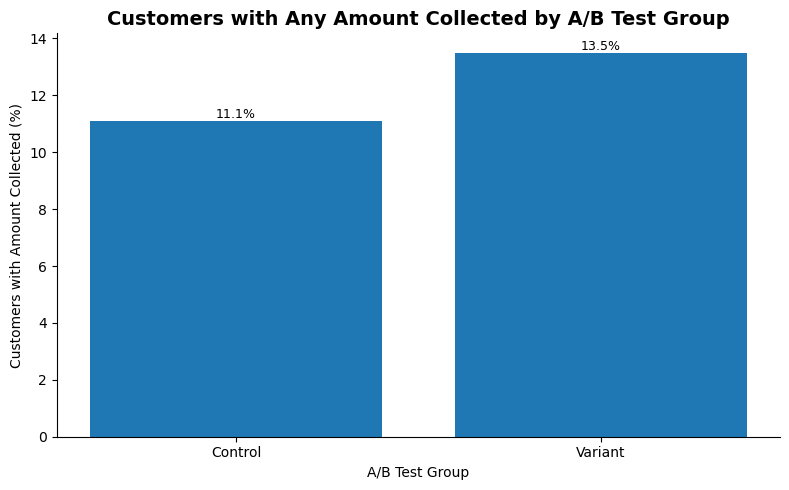

In [24]:
# 8. Plot share of customers with any amount collected by A/B test group
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    amount_summary['ab_test_group'],
    amount_summary['collection_customer_rate']
)

ax.set_title('Customers with Any Amount Collected by A/B Test Group', fontsize=14, fontweight='bold')
ax.set_xlabel('A/B Test Group')
ax.set_ylabel('Customers with Amount Collected (%)')

# 9. Add percentage labels
for index, value in enumerate(amount_summary['collection_customer_rate']):
    ax.text(index, value, f'{value:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'ab_test_collection_customer_rate_by_group.png'), dpi=300, bbox_inches='tight')
plt.show()

**Insight & Business Takeaway**

The t-test gives a statistical view of whether the difference in average amount collected per customer is meaningful. However, amount collected should be interpreted carefully because collections data is naturally zero-heavy and skewed.

The additional collection-rate view helps show what share of customers generated any collected amount, rather than only looking at the average amount collected. This is useful because a higher average can sometimes be driven by a smaller number of larger payments.

**Indication:** Amount collected should be interpreted alongside payment rate, repayment plan setup rate, first instalment paid rate, and customer recovery rate. The commercial result supports the A/B test story, but the final recommendation should be based on the full behaviour pattern rather than a single amount metric.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 10: A/B Test by Balance Band
</h2>

**Analyse Whether Message Performance Differs by Balance Band**

The overall A/B test shows that the supportive Variant message improves several key outcomes, especially repayment plan setup. However, the same message may not work equally well for every customer segment.

In this section, I am analysing A/B test performance by customer balance band. This helps identify whether the supportive message works better for Low, Medium, or High balance customers.

This is important because lower-balance customers may be more likely to make immediate payments, while medium or higher-balance customers may need more flexible repayment options.

In [25]:
# ============================================================
# Section 10: A/B Test by Balance Band
# ============================================================

# 1. Display SQL-exported A/B test performance by balance band
ab_test_by_balance_band

,balance_band,ab_test_group,test_customers,link_open_rate,payment_rate,one_off_payment_rate,plan_setup_rate,total_amount_collected,avg_customer_recovery_rate
0,Low,Control,332,43.07,13.86,11.45,2.71,"5,415.79",11.26
1,Low,Variant,331,44.71,15.11,9.97,6.95,"5,114.51",11.83
2,Medium,Control,387,37.98,8.53,3.10,8.27,"9,871.74",3.74
3,Medium,Variant,465,44.95,13.12,2.58,12.69,"14,285.00",5.85
4,High,Control,210,40.95,11.43,6.19,7.62,"12,533.70",2.74
5,High,Variant,211,41.71,11.85,1.42,11.37,"17,203.78",3.76


In [26]:
# 2. Apply business order to balance bands
balance_order = ['Low', 'Medium', 'High', 'Very High']

balance_band_ab = ab_test_by_balance_band.copy()

balance_band_ab['balance_band'] = pd.Categorical(
    balance_band_ab['balance_band'],
    categories=balance_order,
    ordered=True
)

balance_band_ab = balance_band_ab.sort_values(['balance_band', 'ab_test_group'])

balance_band_ab

,balance_band,ab_test_group,test_customers,link_open_rate,payment_rate,one_off_payment_rate,plan_setup_rate,total_amount_collected,avg_customer_recovery_rate
0,Low,Control,332,43.07,13.86,11.45,2.71,"5,415.79",11.26
1,Low,Variant,331,44.71,15.11,9.97,6.95,"5,114.51",11.83
2,Medium,Control,387,37.98,8.53,3.10,8.27,"9,871.74",3.74
3,Medium,Variant,465,44.95,13.12,2.58,12.69,"14,285.00",5.85
4,High,Control,210,40.95,11.43,6.19,7.62,"12,533.70",2.74
5,High,Variant,211,41.71,11.85,1.42,11.37,"17,203.78",3.76


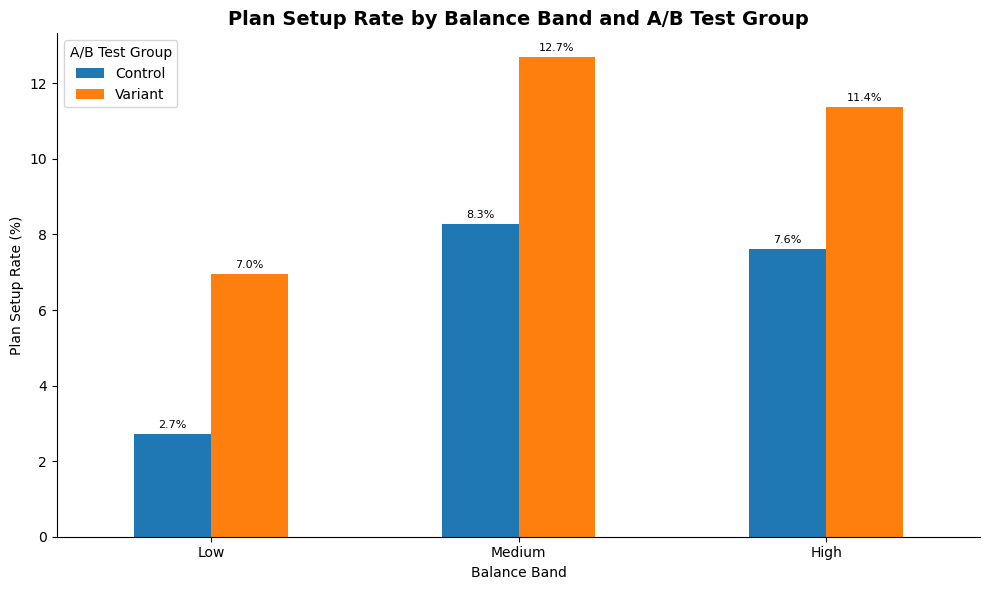

In [27]:
# 3. Create pivot table for plan setup rate by balance band and A/B group
plan_setup_pivot = balance_band_ab.pivot(
    index='balance_band',
    columns='ab_test_group',
    values='plan_setup_rate'
)

# 4. Plot repayment plan setup rate by balance band
fig, ax = plt.subplots(figsize=(10, 6))

plan_setup_pivot.plot(
    kind='bar',
    ax=ax
)

ax.set_title('Plan Setup Rate by Balance Band and A/B Test Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Balance Band')
ax.set_ylabel('Plan Setup Rate (%)')
ax.legend(title='A/B Test Group')

plt.xticks(rotation=0)

# 5. Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8, padding=3)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'ab_test_plan_setup_by_balance_band.png'), dpi=300, bbox_inches='tight')
plt.show()

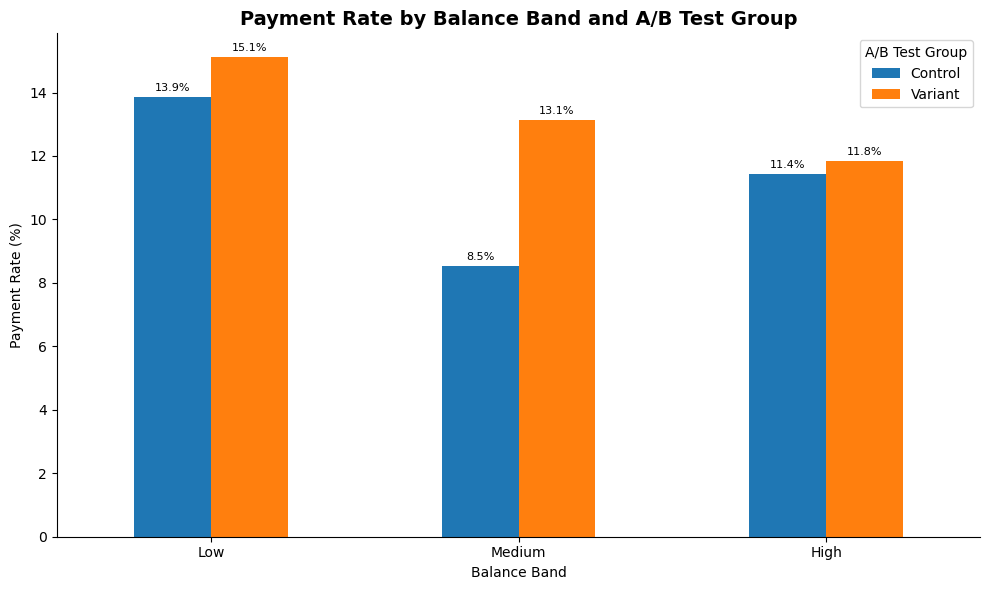

In [28]:
# 6. Create pivot table for payment rate by balance band and A/B group
payment_rate_pivot = balance_band_ab.pivot(
    index='balance_band',
    columns='ab_test_group',
    values='payment_rate'
)

# 7. Plot payment rate by balance band
fig, ax = plt.subplots(figsize=(10, 6))

payment_rate_pivot.plot(
    kind='bar',
    ax=ax
)

ax.set_title('Payment Rate by Balance Band and A/B Test Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Balance Band')
ax.set_ylabel('Payment Rate (%)')
ax.legend(title='A/B Test Group')

plt.xticks(rotation=0)

# 8. Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=8, padding=3)

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_PATH, 'ab_test_payment_rate_by_balance_band.png'), dpi=300, bbox_inches='tight')
plt.show()

In [29]:
# 9. Run plan setup z-tests separately for each balance band
balance_band_test_results = []

for balance_band in ['Low', 'Medium', 'High']:
    
    subset = ab_test_customers[
        ab_test_customers['balance_band'] == balance_band
    ]
    
    result = run_proportion_ztest(
        dataframe=subset,
        metric_column='repayment_plan_created_flag',
        metric_name=f'Plan Setup Rate - {balance_band} Balance'
    )
    
    result['balance_band'] = balance_band
    balance_band_test_results.append(result)

# 10. Convert balance-band test results into a dataframe
balance_band_plan_tests = pd.DataFrame(balance_band_test_results)

# 11. Select and round relevant columns
balance_band_plan_tests = balance_band_plan_tests[
    [
        'balance_band',
        'metric',
        'control_rate_percent',
        'variant_rate_percent',
        'lift_percentage_points',
        'z_statistic',
        'p_value',
        'significance',
        'direction'
    ]
].copy()

balance_band_plan_tests[
    [
        'control_rate_percent',
        'variant_rate_percent',
        'lift_percentage_points',
        'z_statistic',
        'p_value'
    ]
] = balance_band_plan_tests[
    [
        'control_rate_percent',
        'variant_rate_percent',
        'lift_percentage_points',
        'z_statistic',
        'p_value'
    ]
].round(4)

balance_band_plan_tests

,balance_band,metric,control_rate_percent,variant_rate_percent,lift_percentage_points,z_statistic,p_value,significance,direction
0,Low,Plan Setup Rate - Low Balance,2.71,6.95,4.24,2.55,0.01,Statistically significant,Variant higher
1,Medium,Plan Setup Rate - Medium Balance,8.27,12.69,4.42,2.08,0.04,Statistically significant,Variant higher
2,High,Plan Setup Rate - High Balance,7.62,11.37,3.76,1.31,0.19,Not statistically significant,Variant higher


**Insight & Business Takeaway**

The balance-band analysis shows that the Variant message does not simply perform better in the same way for every customer segment.

The most important pattern is repayment plan setup. Segment-level analysis indicates that supportive messaging is more effective for customers with Medium and High balances, while Low-balance customers respond well to direct reminders.

**Indication:** The strongest strategy is not to choose one universal message. DebtStream should use balance-band segmentation to decide when to use direct payment reminders and when to use supportive repayment-option messaging.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 11: Final Business Recommendation
</h2>

**Translate A/B Test Results into Messaging Strategy**

This section summarises the final recommendation from the SMS A/B test.

The goal is to turn the experiment results into a practical customer messaging strategy for DebtStream.

## Final Recommendation

The A/B test shows that the supportive repayment-options message is stronger for encouraging customers to continue into repayment behaviour, especially repayment plan setup.

**Key findings:**

**1. The Variant message improved overall engagement and repayment behaviour.**  
The supportive message delivered higher link open rate, payment rate, repayment plan setup rate, first instalment paid rate, average recovery rate, and average amount collected per customer.

**2. The Control message still performed better for one-off payment rate.**  
This suggests that a direct payment reminder may work better for customers who are already ready to make an immediate payment.

**3. Repayment plan setup is the strongest business case for the Variant.**  
The supportive message produced a meaningful lift in plan setup rate, which aligns with the message objective of encouraging flexible repayment options.

**4. Balance band should guide message strategy.**  
Low-balance customers may respond well to direct payment reminders, while Medium and High balance customers are better candidates for supportive repayment-option messaging.

## Recommended Messaging Strategy

DebtStream should adopt a segmented SMS strategy rather than replacing one message with the other across all customers.

**Use direct payment reminders for:**

- customers with lower balances,
- customers more likely to pay immediately,
- customers who have already shown payment intent.

**Use supportive repayment-option messaging for:**

- Medium and High balance customers,
- customers who may need flexibility,
- customers who are less likely to make an immediate one-off payment,
- customers who may benefit from repayment plan guidance.

## Business Impact

This approach allows DebtStream to optimise for both commercial outcomes:

- immediate one-off payment where the customer is ready to pay,
- repayment plan setup where the customer needs flexibility.

**Final conclusion:** The Variant message is not simply a universal replacement for the Control message. It is most valuable as part of a segmented collections messaging strategy.

<h2 style="color: #F47B20; border-bottom: 2px solid #D9E2EC; padding-bottom: 8px; margin-top: 40px; font-weight: bold;">
Section 12: Export Confirmation
</h2>

**Export Final A/B Test Outputs**

In this final section, I am exporting the key Python-generated A/B test outputs from this notebook.

These outputs can be used later in the final portfolio case study, project documentation, or Power BI validation.

In [30]:
# ============================================================
# Section 12: Export Final A/B Test Outputs
# ============================================================

# 1. Export z-test results from Section 8
ztest_results_df.to_csv(
    os.path.join(SUMMARY_TABLES_PATH, 'python_ab_test_ztest_results.csv'),
    index=False
)

# 2. Export amount collected t-test result from Section 9
amount_ttest_result.to_csv(
    os.path.join(SUMMARY_TABLES_PATH, 'python_ab_test_amount_ttest_result.csv'),
    index=False
)

# 3. Export balance-band plan setup test results from Section 10
balance_band_plan_tests.to_csv(
    os.path.join(SUMMARY_TABLES_PATH, 'python_ab_test_balance_band_plan_tests.csv'),
    index=False
)

print("Python-generated A/B test result tables exported successfully.")

Python-generated A/B test result tables exported successfully.


In [31]:
# 4. List A/B test charts exported from this notebook
ab_test_charts = sorted([
    file for file in os.listdir(CHARTS_PATH)
    if file.startswith('ab_test_')
])

ab_test_charts

['ab_test_amount_collected_distribution.png',
 'ab_test_avg_amount_collected_by_group.png',
 'ab_test_avg_amount_collected_per_customer.png',
 'ab_test_collection_customer_rate_by_group.png',
 'ab_test_control_vs_variant_core_rates.png',
 'ab_test_customer_count_by_group.png',
 'ab_test_payment_rate_by_balance_band.png',
 'ab_test_plan_setup_by_balance_band.png',
 'ab_test_variant_lift_summary.png']

In [32]:
# 5. List Python-generated A/B test summary tables
ab_test_summary_tables = sorted([
    file for file in os.listdir(SUMMARY_TABLES_PATH)
    if file.startswith('python_ab_test_')
])

ab_test_summary_tables

['python_ab_test_amount_ttest_result.csv',
 'python_ab_test_balance_band_plan_tests.csv',
 'python_ab_test_ztest_results.csv']

## Summary

This completes the SMS A/B testing analysis.

The next notebook will focus on repayment, recovery, affordability assessment, and customer segment performance.